## Before my best attempt, everything else was for testing, and most of the code is unusable in nature, and/or produce bad results, you can always skip to the best version.

In [10]:
# (Run this once at the top of your Kaggle notebook to install extras)
!pip install transformers datasets evaluate timm


In [20]:
import os, glob, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, losses, metrics

# --- 1. GPU Configuration ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# --- 2. Paths & Hyperparams ---
BASE_PATH      = '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl'
IMG_DIR        = os.path.join(BASE_PATH, 'images', 'edr')
TRAIN_MASK_DIR = os.path.join(BASE_PATH, 'labels', 'train')
VAL_MASK_DIR   = os.path.join(BASE_PATH, 'labels', 'test', 'masked-gold-min3-100agree')

IMG_HEIGHT, IMG_WIDTH = 256, 256
NUM_CLASSES           = 4
BATCH_SIZE            = 16
LEARNING_RATE         = 1e-4
EPOCHS                = 50
TRAIN_SUBSET          = 1000

# --- 3. Gather (image, mask) file pairs ---
def get_pairs(mask_dir, img_dir, val=False):
    pairs = []
    for m in glob.glob(os.path.join(mask_dir, '*.png')):
        base = os.path.basename(m)[:-4]
        if val and base.endswith('_merged'):
            base = base[:-7]
        for ext in ('.JPG', '.jpg', '.jpeg'):
            img = os.path.join(img_dir, base + ext)
            if os.path.exists(img):
                pairs.append((img, m))
                break
    random.shuffle(pairs)
    return pairs

train_pairs = get_pairs(TRAIN_MASK_DIR, IMG_DIR)[:TRAIN_SUBSET]
val_pairs   = get_pairs(VAL_MASK_DIR, IMG_DIR, val=True)

# --- 4. tf.data Pipeline ---
def parse_and_preprocess(img_path, mask_path, training=False):
    # Load & resize image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    # Load & resize mask
    m = tf.io.read_file(mask_path)
    m = tf.image.decode_png(m, channels=1)
    m = tf.image.resize(m, [IMG_HEIGHT, IMG_WIDTH], method='nearest')
    m = tf.cast(m, tf.int32)

    # Augmentation
    if training:
        if tf.random.uniform(()) > 0.5:
            img, m = tf.image.flip_left_right(img), tf.image.flip_left_right(m)
        if tf.random.uniform(()) > 0.5:
            img, m = tf.image.flip_up_down(img), tf.image.flip_up_down(m)
        k = tf.random.uniform((), 0, 4, tf.int32)
        img, m = tf.image.rot90(img, k), tf.image.rot90(m, k)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.8, 1.2)

    # Normalize to [0,1]
    img = tf.cast(img, tf.float32) / 255.0
    # One-hot encode mask
    mask = tf.one_hot(tf.squeeze(m, -1), NUM_CLASSES)

    return img, mask

def make_dataset(pairs, training=False):
    imgs, masks = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(imgs), list(masks)))
    if training:
        ds = ds.shuffle(len(imgs))
    ds = ds.map(lambda x, y: parse_and_preprocess(x, y, training),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_pairs, training=True)
val_ds   = make_dataset(val_pairs,   training=False)

# --- 5. U-Net with EfficientNetB0 Encoder + Extra Upsample ---
def build_unet_efficientnet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    # Encoder: EfficientNetB0
    base = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape, include_top=False, weights='imagenet')
    skip_names = [
        'block2a_expand_activation',  # 128×128
        'block3a_expand_activation',  # 64×64
        'block4a_expand_activation',  # 32×32
        'block6a_expand_activation'   # 16×16
    ]
    skips = [base.get_layer(name).output for name in skip_names]
    x = base.output  # shape ~ 8×8

    # Decoder: four upsampling + skip connections -> shape becomes 128×128
    for filters, skip in zip([512, 256, 128, 64], reversed(skips)):
        x = layers.Conv2DTranspose(filters, (2,2), strides=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)

    # **Extra upsampling** from 128×128 -> 256×256
    x = layers.Conv2DTranspose(32, (2,2), strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Final 1×1 conv to get num_classes channels
    outputs = layers.Conv2D(num_classes, 1, padding='same', activation='softmax')(x)

    return models.Model(inputs=base.input, outputs=outputs)

model = build_unet_efficientnet()

# --- 6. Combined Focal + Dice + Label-Smoothing Loss ---
class CombinedLoss(tf.keras.losses.Loss):
    def __init__(self, smooth=0.1, gamma=2.0, alpha=0.25):
        super().__init__()
        self.smooth, self.gamma, self.alpha = smooth, gamma, alpha

    def call(self, y_true, y_pred):
        # 1) Label smoothing
        y_true = y_true * (1 - self.smooth) + self.smooth / NUM_CLASSES

        # 2) Numerical stability
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # 3) Focal component (sum over H, W, C → [batch])
        ce     = -y_true * tf.math.log(y_pred)
        weight = self.alpha * tf.pow(1 - y_pred, self.gamma)
        focal  = tf.reduce_sum(weight * ce, axis=[1, 2, 3])

        # 4) Dice component (already [batch])
        inter = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
        union = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])
        dice  = 1 - (2 * inter + 1e-6) / (union + 1e-6)

        # 5) Combine and average
        loss_per_sample = focal + dice   # shape [batch]
        return tf.reduce_mean(loss_per_sample)


# --- 7. Compile the Model ---
model.compile(
    optimizer=optimizers.Adam(LEARNING_RATE),
    loss=CombinedLoss(),
    metrics=[
        metrics.MeanIoU(num_classes=NUM_CLASSES),
        metrics.CategoricalAccuracy()
    ]
)

# --- 8. Callbacks & Training ---
cbs = [
    callbacks.ModelCheckpoint(
        'best_unet.keras',    # must end in .keras in Keras 3
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        mode='min'
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cbs
)

# --- 9. Final Evaluation ---
print("Final evaluation:", model.evaluate(val_ds, return_dict=True))


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - categorical_accuracy: 0.2352 - loss: 9762.1074 - mean_io_u_10: 0.2906 - val_categorical_accuracy: 0.3126 - val_loss: 5247.6929 - val_mean_io_u_10: 0.3483
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - categorical_accuracy: 0.5954 - loss: 4649.6670 - mean_io_u_10: 0.2900 - val_categorical_accuracy: 0.4558 - val_loss: 5118.5786 - val_mean_io_u_10: 0.3483
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - categorical_accuracy: 0.6417 - loss: 3820.2053 - mean_io_u_10: 0.2898 - val_categorical_accuracy: 0.1046 - val_loss: 6288.9351 - val_mean_io_u_10: 0.3483
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - categorical_accuracy: 0.6244 - loss: 3479.5994 - mean_io_u_10: 0.2904 - val_categorical_accuracy: 0.1112 - val_loss: 5999.9365 - val_mean_io_u_10: 0.3483
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - categorical_accuracy: 0.6380 - loss: 3425.8489 - mean_io_u_10: 0.2889 - val_categorical_accuracy: 0.1048 - val_

In [31]:
import os
import glob
import random
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, metrics
import albumentations as A

# --- 0) Force float32 global policy to avoid any f16/f32 mixing ---
tf.keras.mixed_precision.set_global_policy('float32')

# --- Config ---
BASE_PATH    = '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl'
IMG_DIR      = os.path.join(BASE_PATH, 'images', 'edr')
TRAIN_MASK   = os.path.join(BASE_PATH, 'labels', 'train')
VAL_MASK     = os.path.join(BASE_PATH, 'labels', 'test', 'masked-gold-min3-100agree')
IMG_SIZE     = (256, 256)
NUM_CLASSES  = 4
BATCH_SIZE   = 16
LR           = 1e-4
EPOCHS       = 50
SUBSET_TRAIN = 1000

# --- 1) Gather image–mask file pairs ---
def get_pairs(mask_dir, img_dir, val=False):
    pairs = []
    for m in glob.glob(f"{mask_dir}/*.png"):
        base = os.path.basename(m)[:-4]
        if val and base.endswith('_merged'):
            base = base[:-7]
        for ext in ('.jpg', '.JPG', '.jpeg'):
            im = os.path.join(img_dir, base + ext)
            if os.path.exists(im):
                pairs.append((im, m))
                break
    random.shuffle(pairs)
    return pairs

train_pairs = get_pairs(TRAIN_MASK, IMG_DIR)[:SUBSET_TRAIN]
val_pairs   = get_pairs(VAL_MASK, IMG_DIR, val=True)

# --- 2) Albumentations augmentation pipeline ---
train_aug = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Transpose(p=0.5),
    A.OneOf([
        A.GridDistortion(p=0.5),
        A.ElasticTransform(p=0.5),
        A.OpticalDistortion(p=0.5),
    ], p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CoarseDropout(
        num_holes_range=(1,1),
        hole_height_range=(16,16),
        hole_width_range=(16,16),
        fill=0,
        p=0.5
    ),
], p=1.0)

# --- 3) Data loading + augmentation ---
def load_and_preprocess(img_path, mask_path, training=False):
    # Read & decode image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    # Read & decode mask
    m = tf.io.read_file(mask_path)
    m = tf.image.decode_png(m, channels=1)
    m = tf.image.resize(m, IMG_SIZE, method='nearest')
    m = tf.cast(m, tf.int32)

    if training:
        def aug_fn(image, mask):
            data = train_aug(image=image.numpy(), mask=mask.numpy())
            return data['image'], data['mask']
        img, m = tf.py_function(
            func=aug_fn,
            inp=[img, m],
            Tout=[tf.uint8, tf.uint8]
        )
        # reattach static shapes
        img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
        m.set_shape  ([IMG_SIZE[0], IMG_SIZE[1], 1])

    # Normalize image
    img = tf.cast(img, tf.float32) / 255.0
    # One-hot encode mask
    mask = tf.squeeze(m, axis=-1)
    mask = tf.one_hot(mask, NUM_CLASSES)

    return img, mask

def make_dataset(pairs, training=False):
    img_paths, mask_paths = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(img_paths), list(mask_paths)))
    if training:
        ds = ds.shuffle(buffer_size=len(pairs))
    ds = ds.map(
        lambda i, m: load_and_preprocess(i, m, training),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_pairs, training=True)
val_ds   = make_dataset(val_pairs,   training=False)

# --- 4) DeepLabV3+ with EfficientNetB3 backbone ---
def DeepLabV3Plus(input_shape, num_classes):
    base = tf.keras.applications.EfficientNetB3(
        input_shape=input_shape, include_top=False, weights='imagenet'
    )
    x = base.output  # (None,8,8,1536)

    # ASPP branch: 1×1 conv
    b0 = layers.Conv2D(256, 1, padding='same', activation='relu')(x)

    # ASPP branch: image pooling → conv → dynamic resize
    gp = layers.GlobalAveragePooling2D()(x)
    gp = layers.Reshape((1,1, x.shape[-1]))(gp)
    gp = layers.Conv2D(256, 1, padding='same', activation='relu')(gp)
    def resize_to_x(inputs):
        t, ref = inputs
        size = tf.shape(ref)[1:3]
        return tf.image.resize(t, size, method='bilinear')
    b1 = layers.Lambda(resize_to_x)([gp, x])

    # ASPP dilated convs
    b2 = layers.Conv2D(256, 3, dilation_rate=6,  padding='same', activation='relu')(x)
    b3 = layers.Conv2D(256, 3, dilation_rate=12, padding='same', activation='relu')(x)
    b4 = layers.Conv2D(256, 3, dilation_rate=18, padding='same', activation='relu')(x)

    # Concatenate ASPP
    x = layers.Concatenate()([b0, b1, b2, b3, b4])
    x = layers.Conv2D(256, 1, padding='same', activation='relu')(x)
    x = layers.UpSampling2D((4,4), interpolation='bilinear')(x)  # → (None,32,32,256)

    # Decoder skip connection
    skip = base.get_layer('block3b_add').output  # (None,32,32,384)
    skip = layers.Conv2D(48, 1, padding='same', activation='relu')(skip)
    x    = layers.Concatenate()([x, skip])
    x    = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x    = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x    = layers.UpSampling2D((8,8), interpolation='bilinear')(x)  # → (None,256,256,256)

    # Final classifier
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(x)
    return models.Model(inputs=base.input, outputs=outputs)

model = DeepLabV3Plus(input_shape=(256,256,3), num_classes=NUM_CLASSES)

# --- 5) Compile & Callbacks ---
model.compile(
    optimizer=optimizers.Adam(LR),
    loss='categorical_crossentropy',
    metrics=[metrics.MeanIoU(num_classes=NUM_CLASSES),
             metrics.CategoricalAccuracy()]
)

ckpt = callbacks.ModelCheckpoint(
    'deeplabv3plus.keras', monitor='val_loss',
    save_best_only=True, mode='min'
)
es = callbacks.EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, mode='min'
)

# --- 6) Train ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[ckpt, es]
)


Epoch 1/50


2025-05-01 14:54:08.474466: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng25{k2=1,k3=0} for conv (f32[5184,1536,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[5184,256,1,1]{3,2,1,0}, f32[256,1536,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-05-01 14:54:09.480619: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2.006352588s
Trying algorithm eng25{k2=1,k3=0} for conv (f32[5184,1536,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[5184,256,1,1]{3,2,1,0}, f32[256,1536,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activ

62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - categorical_accuracy: 0.4288 - loss: 2.6391 - mean_io_u_16: 0.2882

2025-05-01 14:55:45.284867: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng25{k2=1,k3=0} for conv (f32[2592,1536,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[2592,256,1,1]{3,2,1,0}, f32[256,1536,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-05-01 14:55:45.289261: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.004594393s
Trying algorithm eng25{k2=1,k3=0} for conv (f32[2592,1536,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[2592,256,1,1]{3,2,1,0}, f32[256,1536,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activ

63/63 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - categorical_accuracy: 0.4269 - loss: 2.9447 - mean_io_u_16: 0.2863 - val_categorical_accuracy: 0.0907 - val_loss: 18.5935 - val_mean_io_u_16: 0.2533
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 488ms/step - categorical_accuracy: 0.2872 - loss: 307.9942 - mean_io_u_16: 0.2863 - val_categorical_accuracy: 2.2992e-04 - val_loss: 497.5449 - val_mean_io_u_16: 0.2054
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 490ms/step - categorical_accuracy: 0.2798 - loss: 5316.8994 - mean_io_u_16: 0.2712 - val_categorical_accuracy: 2.3879e-04 - val_loss: 1726.2816 - val_mean_io_u_16: 0.2054
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 488ms/step - categorical_accuracy: 0.2921 - loss: 27421.8535 - mean_io_u_16: 0.2832 - val_categorical_accuracy: 2.2992e-04 - val_loss: 20375.9941 - val_mean_io_u_16: 0.2054
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 487ms/step - categorical_accuracy: 0.2809 - loss: 82638.7891 - mean_io_u_16: 0.2771 - val_categorical_accuracy: 2.2992e-04 - val

In [32]:
pip install transformers tensorflow albumentations[imgaug] timm


Note: you may need to restart the kernel to use updated packages.


In [38]:
import os
# FORCE legacy Keras so TFPreTrainedModel.compile() works without the `_distribute_strategy` error
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
from transformers import TFSegformerForSemanticSegmentation
from tensorflow.keras import callbacks, optimizers, metrics
import albumentations as A
import numpy as np

# Mixed precision for faster training (requires GPU support)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Paths (adjust to your Kaggle input/output)
BASE_PATH       = '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl'
IMAGE_DIR       = os.path.join(BASE_PATH, 'images', 'edr')
MASK_DIR        = os.path.join(BASE_PATH, 'labels', 'train')
SAVE_MODEL_PATH = '/kaggle/working/segformer_ai4mars.keras'

# Model & training config
IMG_SIZE        = 512
BATCH_SIZE      = 8
EPOCHS          = 30
LR              = 6e-5
NUM_CLASSES     = 4  # e.g., rock, soil, sand, dust (as per AI4Mars) :contentReference[oaicite:3]{index=3}
id2label        = {0: 'soil', 1: 'rock', 2: 'sand', 3: 'dust'}
label2id        = {v: k for k, v in id2label.items()}


In [39]:
# Albumentations augmentation pipeline
train_aug = A.Compose([
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.OneOf([A.GridDistortion(), A.ElasticTransform(), A.OpticalDistortion()], p=0.5),
    A.RandomBrightnessContrast(p=0.5),
], p=1.0)

# SegFormer pre-training normalization stats :contentReference[oaicite:4]{index=4}
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_image_mask(img_path, mask_path, training=False):
    # Read & resize
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method='nearest')
    
    # To numpy for Albumentations
    img_np  = img.numpy().astype(np.uint8)
    mask_np = mask.numpy().astype(np.uint8)
    if training:
        aug = train_aug(image=img_np, mask=mask_np)
        img_np, mask_np = aug['image'], aug['mask']
    
    # Normalize & transpose to channels-first
    img_np = img_np.astype(np.float32) / 255.0
    img_np = (img_np - MEAN) / STD
    img_tf = tf.transpose(img_np, perm=(2, 0, 1))
    
    # Prepare labels
    mask_np = mask_np.squeeze().astype(np.int32)
    return {"pixel_values": img_tf}, mask_np

def tf_load(img_path, mask_path, training=False):
    # Wrap py_function to use inside tf.data
    out_img, out_mask = tf.py_function(
        lambda i, m: load_image_mask(i, m, training),
        [img_path, mask_path],
        [tf.float32, tf.int32]
    )
    out_img.set_shape((3, IMG_SIZE, IMG_SIZE))
    out_mask.set_shape((IMG_SIZE, IMG_SIZE))
    return {"pixel_values": out_img}, out_mask

def create_dataset(img_paths, mask_paths, training=False):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training: ds = ds.shuffle(len(img_paths))
    ds = ds.map(lambda i, m: tf_load(i, m, training),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [40]:
import glob, random

# Collect all image–mask pairs
mask_paths = glob.glob(os.path.join(MASK_DIR, '*.png'))
img_paths  = [os.path.join(IMAGE_DIR,
               os.path.basename(p).replace('.png', '.JPG'))
              for p in mask_paths]

# Split into train/val (e.g., 80/20)
data = list(zip(img_paths, mask_paths))
random.shuffle(data)
split = int(0.8 * len(data))
train_pairs, val_pairs = data[:split], data[split:]

train_ds = create_dataset(
    [p[0] for p in train_pairs],
    [p[1] for p in train_pairs],
    training=True
)
val_ds = create_dataset(
    [p[0] for p in val_pairs],
    [p[1] for p in val_pairs],
    training=False
)


In [41]:
# Based on “Unified Focal Loss” repository :contentReference[oaicite:5]{index=5}
def unified_focal_loss(y_true, y_pred, alpha=0.5, gamma=0.5):
    # y_pred: logits [B, C, H, W] → probabilities
    y_pred = tf.nn.softmax(y_pred, axis=1)
    y_true = tf.one_hot(y_true, NUM_CLASSES)              # [B, H, W, C]
    y_true = tf.transpose(y_true, perm=(0, 3, 1, 2))       # [B, C, H, W]
    
    ce = -y_true * tf.math.log(tf.clip_by_value(y_pred,1e-8,1.0))
    w  = alpha * tf.pow(1 - y_pred, gamma)
    focal = tf.reduce_sum(w * ce, axis=1)                  # per-pixel loss
    dice  = 1 - (2 * tf.reduce_sum(y_pred * y_true, axis=[1,2,3]) + 1e-6) \
                  / (tf.reduce_sum(y_pred + y_true, axis=[1,2,3]) + 1e-6)
    return tf.reduce_mean(focal + dice)


In [42]:
# after setting TF_USE_LEGACY_KERAS above…

model = TFSegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
model.compile(
    optimizer=optimizer,
    loss=unified_focal_loss,
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="cat_acc"),
        tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES, name="mean_iou")
    ]
)



Some layers from the model checkpoint at nvidia/mit-b0 were not used when initializing TFSegformerForSemanticSegmentation: ['classifier']
- This IS expected if you are initializing TFSegformerForSemanticSegmentation from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSegformerForSemanticSegmentation from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFSegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: 'Variable' object has no attribute '_distribute_strategy'

In [ ]:
class DisplayCallback(callbacks.Callback):
    def __init__(self, ds, num=1):
        self.ds = ds; self.num = num
    def on_epoch_end(self, epoch, logs=None):
        batch = next(iter(self.ds))
        imgs, masks = batch["pixel_values"], batch[1]
        preds = model.predict(imgs).logits
        pred_labels = tf.argmax(preds, axis=1)
        # Display first sample
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(tf.transpose(imgs[0], (1,2,0))); plt.title("Image")
        plt.subplot(1,3,2)
        plt.imshow(masks[0]); plt.title("True Mask")
        plt.subplot(1,3,3)
        plt.imshow(pred_labels[0]); plt.title("Pred Mask")
        plt.show()

cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(SAVE_MODEL_PATH, save_best_only=True, monitor="val_loss"),
    DisplayCallback(val_ds)
]


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cbs
)


In [ ]:
# Load best weights
best_model = tf.keras.models.load_model(
    SAVE_MODEL_PATH,
    custom_objects={"unified_focal_loss": unified_focal_loss}
)
results = best_model.evaluate(val_ds)
print(dict(zip(best_model.metrics_names, results)))


In [1]:
!pip install torch torchvision
!pip install segmentation-models-pytorch albumentations timm


In [45]:
import os
import torch
import numpy as np
import albumentations as A
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from albumentations.pytorch import ToTensorV2


In [46]:
class MarsDataset(Dataset):
    def __init__(self, image_paths, mask_paths, augment=None, preprocess=None):
        self.images = image_paths
        self.masks  = mask_paths
        self.aug    = augment
        self.prep   = preprocess

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[idx], cv2.IMREAD_UNCHANGED)

        if self.aug:
            aug = self.aug(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']

        if self.prep:
            pre = self.prep(image=img, mask=mask)
            img, mask = pre['image'], pre['mask']

        return img, mask.long()

# Augmentations
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.OneOf([
        A.OpticalDistortion(p=0.3), A.GridDistortion(p=0.3),
        A.ElasticTransform(p=0.3),
    ], p=0.5),
    A.RandomBrightnessContrast(p=0.5),
], p=1.0)

# Preprocessing: SMP provides the backbone’s preprocessing fn
preprocess_input = smp.encoders.get_preprocessing_fn('efficientnet-b3', pretrained='imagenet')
prep = A.Compose([
    A.Normalize(mean=preprocess_input.mean, std=preprocess_input.std),
    ToTensorV2(),
])


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:58: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

AttributeError: 'functools.partial' object has no attribute 'mean'

In [ ]:
NUM_CLASSES = 4

# 1) Choose backbone and build UNet
model = smp.Unet(
    encoder_name='efficientnet-b3',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,  # logits
)

# 2) Loss: combined Dice + Focal for class imbalance
dice_loss  = smp.losses.DiceLoss(mode='multiclass')
focal_loss = smp.losses.FocalLoss(mode='multiclass')
def loss_fn(outputs, targets):
    return dice_loss(outputs, targets) + focal_loss(outputs, targets)

# 3) Metrics
metric_iou  = smp.utils.metrics.IoU(threshold=0.5)


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_ds = MarsDataset(train_imgs, train_masks, augment=train_aug, preprocess=prep)
val_ds   = MarsDataset(val_imgs,   val_masks,   augment=None,     preprocess=prep)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

best_iou = 0.0
for epoch in range(1, 61):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = loss_fn(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, val_iou = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_loss += loss_fn(preds, masks).item()
            val_iou  += metric_iou(preds, masks).item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_iou     /= len(val_loader)

    print(f"Epoch {epoch:02d} — Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  Val IoU: {val_iou:.4f}")

    # Save best
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), 'best_model.pth')


In [ ]:
!pip install pytorch-lightning

import pytorch_lightning as pl

class MarsSegmentationModule(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model   = model
        self.loss_fn = loss_fn

    def forward(self, x): return self.model(x)

    def training_step(self, batch, batch_idx):
        imgs, masks = batch
        preds = self(imgs)
        loss  = self.loss_fn(preds, masks)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, masks = batch
        preds = self(imgs)
        loss  = self.loss_fn(preds, masks)
        iou   = metric_iou(preds, masks)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_iou',  iou,  prog_bar=True)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=1e-4)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', patience=5)
        return {'optimizer':opt, 'lr_scheduler':{'scheduler':sch, 'monitor':'val_loss'}}

trainer = pl.Trainer(
    gpus=1, max_epochs=60,
    precision=16,  # mixed precision
    callbacks=[pl.callbacks.ModelCheckpoint(monitor='val_iou', mode='max')]
)
trainer.fit(trainer, train_loader, val_loader)


In [1]:
!pip install torch torchvision
!pip install segmentation-models-pytorch albumentations timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-1

In [3]:
import os
import glob
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1) Paths & constants
BASE      = '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl'
IMG_DIR   = os.path.join(BASE, 'images', 'edr')
MASK_TRAIN_DIR = os.path.join(BASE, 'labels', 'train')
MASK_VAL_DIR   = os.path.join(BASE, 'labels', 'test', 'masked-gold-min3-100agree')

IMG_SIZE   = 256
BATCH_SIZE = 4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4

# 2) Helper to pair images ←→ masks
def get_pairs(mask_dir, img_dir):
    mask_paths = sorted(glob.glob(os.path.join(mask_dir, '*.png')))
    pairs = []
    for m in mask_paths:
        base = os.path.basename(m).rsplit('.',1)[0]
        # try .JPG/.jpg
        for ext in ['.jpg','.JPG','.jpeg','.JPEG']:
            img_path = os.path.join(img_dir, base + ext)
            if os.path.isfile(img_path):
                pairs.append((img_path, m))
                break
        else:
            # no image found for this mask
            print(f"Warning: no image for mask {m}")
    return pairs

train_pairs = get_pairs(MASK_TRAIN_DIR, IMG_DIR)
val_pairs   = get_pairs(MASK_VAL_DIR,   IMG_DIR)

print(f"Found {len(train_pairs)} training pairs")
print(f"Found {len(val_pairs)} validation pairs")

# 3) If validation is empty, split train into train/val
if len(val_pairs) == 0:
    print("No validation masks found; splitting off 20% of training set for validation.")
    random.shuffle(train_pairs)
    split = int(0.8 * len(train_pairs))
    val_candidates = train_pairs[split:]
    train_pairs    = train_pairs[:split]
    val_pairs      = val_candidates

print(f"Using {len(train_pairs)} train pairs, {len(val_pairs)} val pairs")

# 4) Dataset & transforms
class MarsDataset(Dataset):
    def __init__(self, pairs, augment):
        self.pairs    = pairs
        self.augment  = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, msk_p = self.pairs[idx]
        img = cv2.imread(img_p)[:,:,::-1]  # BGR→RGB
        msk = cv2.imread(msk_p, cv2.IMREAD_UNCHANGED)
        data = self.augment(image=img, mask=msk)
        return data['image'], data['mask'].long()

train_aug = A.Compose([
    A.Resize(IMG_SIZE,IMG_SIZE),
    A.HorizontalFlip(0.5),
    A.RandomRotate90(0.5),
    A.Affine(rotate=(-15,15), scale=(0.9,1.1), p=0.5),
    A.RandomBrightnessContrast(0.5),
    A.Normalize(),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE,IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

train_ds = MarsDataset(train_pairs, augment=train_aug)
val_ds   = MarsDataset(val_pairs,   augment=val_aug)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# 5) Model, loss, optimizer
model = smp.Unet(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# 6) Training loop (no fancy AMP for clarity)
EPOCHS = 20
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch:02d} — train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}")


Found 16064 training pairs
Found 0 validation pairs
No validation masks found; splitting off 20% of training set for validation.
Using 12851 train pairs, 3213 val pairs


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 01 — train_loss: 0.5564, val_loss: 0.2334
Epoch 02 — train_loss: 0.3756, val_loss: 0.2189
Epoch 03 — train_loss: 0.3319, val_loss: 0.1883
Epoch 04 — train_loss: 0.2981, val_loss: 0.1678
Epoch 05 — train_loss: 0.2763, val_loss: 0.1475
Epoch 06 — train_loss: 0.2705, val_loss: 0.1585


KeyboardInterrupt: 

## At the moment, this is the best version of the model, this version is faster at training, and takes a smaller amount of the dataset to train.
### This also has a deployment testing at the end, there are two takes for it, one is using 5 specific images, it doesnt change, but the second changes every run.
### And for the colors of the testing part, here are the distinctions, Blue regions are Sand, Orange regions are Bedrock, Green regions are Soil, Red regions are Big Rock



In [4]:
import os
import glob
import random
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1) Paths & constants
BASE            = '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl'
IMG_DIR         = os.path.join(BASE, 'images', 'edr')
MASK_TRAIN_DIR  = os.path.join(BASE, 'labels', 'train')
MASK_VAL_DIR    = os.path.join(BASE, 'labels', 'test', 'masked-gold-min3-100agree')

IMG_SIZE   = 256
BATCH_SIZE = 4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
SUBSAMPLE_SIZE = 3000  # use only 3000 images for faster training

# 2) Helper to pair images ←→ masks
def get_pairs(mask_dir, img_dir):
    mask_paths = sorted(glob.glob(os.path.join(mask_dir, '*.png')))  # mask loader :contentReference[oaicite:6]{index=6}
    pairs = []
    for m in mask_paths:
        base = os.path.basename(m).rsplit('.', 1)[0]
        for ext in ['.jpg','.JPG','.jpeg','.JPEG']:
            img_path = os.path.join(img_dir, base + ext)
            if os.path.isfile(img_path):
                pairs.append((img_path, m))
                break
        else:
            print(f"Warning: no image for mask {m}")
    return pairs

train_pairs = get_pairs(MASK_TRAIN_DIR, IMG_DIR)
val_pairs   = get_pairs(MASK_VAL_DIR,   IMG_DIR)

# 3) If no explicit validation, split 20% off training
if not val_pairs:
    random.shuffle(train_pairs)                                     # subsample requires random.sample :contentReference[oaicite:7]{index=7}
    # subsample to SUBSAMPLE_SIZE first
    train_pairs = random.sample(train_pairs, min(SUBSAMPLE_SIZE, len(train_pairs)))
    split = int(0.8 * len(train_pairs))
    val_pairs = train_pairs[split:]
    train_pairs = train_pairs[:split]
else:
    # if validation exists, just subsample train
    train_pairs = random.sample(train_pairs, min(SUBSAMPLE_SIZE, len(train_pairs)))

print(f"Using {len(train_pairs)} train pairs, {len(val_pairs)} val pairs")

# 4) Dataset & transforms
class MarsDataset(Dataset):
    def __init__(self, pairs, augment):
        self.pairs   = pairs
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_p, msk_p = self.pairs[idx]
        img = cv2.imread(img_p)[:,:,::-1]      # BGR→RGB conversion :contentReference[oaicite:8]{index=8}
        msk = cv2.imread(msk_p, cv2.IMREAD_UNCHANGED)
        data = self.augment(image=img, mask=msk)
        return data['image'], data['mask'].long()

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(rotate=(-15,15), scale=(0.9,1.1), p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(),                         # Albumentations normalization :contentReference[oaicite:9]{index=9}
    ToTensorV2(),                          # convert to torch.Tensor :contentReference[oaicite:10]{index=10}
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

train_ds = MarsDataset(train_pairs, augment=train_aug)
val_ds   = MarsDataset(val_pairs,   augment=val_aug)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True             # DataLoader performance tips :contentReference[oaicite:11]{index=11}
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

# 5) Model, loss, optimizer
model = smp.Unet(
    encoder_name='efficientnet-b0',           # U-Net w/ EfficientNet-B0 encoder :contentReference[oaicite:12]{index=12}
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=255)  # ignore_index for void pixels :contentReference[oaicite:13]{index=13}
optimizer = optim.AdamW(model.parameters(), lr=1e-4)  # AdamW optimizer :contentReference[oaicite:14]{index=14}

# 6) Training loop
EPOCHS = 20
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch:02d} — train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}")


Using 2400 train pairs, 600 val pairs
Epoch 01 — train_loss: 0.7021, val_loss: 0.2909
Epoch 02 — train_loss: 0.4450, val_loss: 0.2365
Epoch 03 — train_loss: 0.3855, val_loss: 0.2225
Epoch 04 — train_loss: 0.3441, val_loss: 0.1933
Epoch 05 — train_loss: 0.3190, val_loss: 0.1955
Epoch 06 — train_loss: 0.2782, val_loss: 0.1935
Epoch 07 — train_loss: 0.2641, val_loss: 0.1762
Epoch 08 — train_loss: 0.2457, val_loss: 0.1984
Epoch 09 — train_loss: 0.2536, val_loss: 0.1735
Epoch 10 — train_loss: 0.2379, val_loss: 0.1681
Epoch 11 — train_loss: 0.2335, val_loss: 0.1787
Epoch 12 — train_loss: 0.2126, val_loss: 0.1720
Epoch 13 — train_loss: 0.1951, val_loss: 0.1956
Epoch 14 — train_loss: 0.1965, val_loss: 0.1774
Epoch 15 — train_loss: 0.1889, val_loss: 0.1508
Epoch 16 — train_loss: 0.1829, val_loss: 0.1731
Epoch 17 — train_loss: 0.1865, val_loss: 0.1495
Epoch 18 — train_loss: 0.1892, val_loss: 0.1833
Epoch 19 — train_loss: 0.1614, val_loss: 0.1596
Epoch 20 — train_loss: 0.1697, val_loss: 0.1427


In [10]:
import torch

# Assume `model` is your trained segmentation-models-pytorch Unet on DEVICE
model.eval()
scripted = torch.jit.script(model.cpu())                 # compile to TorchScript 
scripted.save('/kaggle/working/segmentation_model.pt')   # write to disk 


In [11]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.jit.load('/kaggle/working/segmentation_model.pt', map_location=device)
model.eval()                                              # ready for inference 


RecursiveScriptModule(
  original_name=Unet
  (encoder): RecursiveScriptModule(
    original_name=EfficientNetEncoder
    (_conv_stem): RecursiveScriptModule(
      original_name=Conv2dStaticSamePadding
      (static_padding): RecursiveScriptModule(original_name=ZeroPad2d)
    )
    (_bn0): RecursiveScriptModule(original_name=BatchNorm2d)
    (_blocks): RecursiveScriptModule(
      original_name=ModuleList
      (0): RecursiveScriptModule(
        original_name=MBConvBlock
        (_expand_conv): RecursiveScriptModule(original_name=Identity)
        (_bn0): RecursiveScriptModule(original_name=Identity)
        (_depthwise_conv): RecursiveScriptModule(
          original_name=Conv2dStaticSamePadding
          (static_padding): RecursiveScriptModule(original_name=ZeroPad2d)
        )
        (_bn1): RecursiveScriptModule(original_name=BatchNorm2d)
        (_se_reduce): RecursiveScriptModule(
          original_name=Conv2dStaticSamePadding
          (static_padding): RecursiveScriptModule

In [17]:
from glob import glob
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256

# example: grab 10 random images from validation directory
val_img_paths = glob('/kaggle/input/ai4mars/.../images/edr/*.jpg')[:10]

# define same preprocessing as used for `val_aug` earlier
preprocess = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2(),
])

def load_and_preprocess(path):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return preprocess(image=img)['image'].unsqueeze(0).to(device)


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def infer_and_plot(img_path):
    input_tensor = load_and_preprocess(img_path)
    with torch.no_grad():
        logits = model(input_tensor)                       # raw outputs :contentReference[oaicite:0]{index=0}
        mask   = logits.argmax(dim=1).cpu().squeeze().numpy()

    # load original for display
    orig = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))

    # simple color map for up to 4 classes
    colors = np.array([
        [0,0,0],        # background
        [255,0,0],      # class1
        [0,255,0],      # class2
        [0,0,255],      # class3
    ], dtype=np.uint8)

    overlay = (0.6 * orig + 0.4 * colors[mask]).astype(np.uint8)

    # plot side by side
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
    ax1.imshow(orig); ax1.set_title('Input Image'); ax1.axis('off')
    ax2.imshow(overlay); ax2.set_title('Segmentation Overlay'); ax2.axis('off')
    plt.show()

for p in val_img_paths:
    infer_and_plot(p)


Running inference on: ['/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLA_397586928EDR_F0010008AUT_04096M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLA_397586934EDR_F0010008AUT_04096M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLA_397681339EDR_F0020000AUT_04096M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLA_397681372EDR_F0020000AUT_04096M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLA_397681398EDR_F0020000AUT_04096M1.JPG']


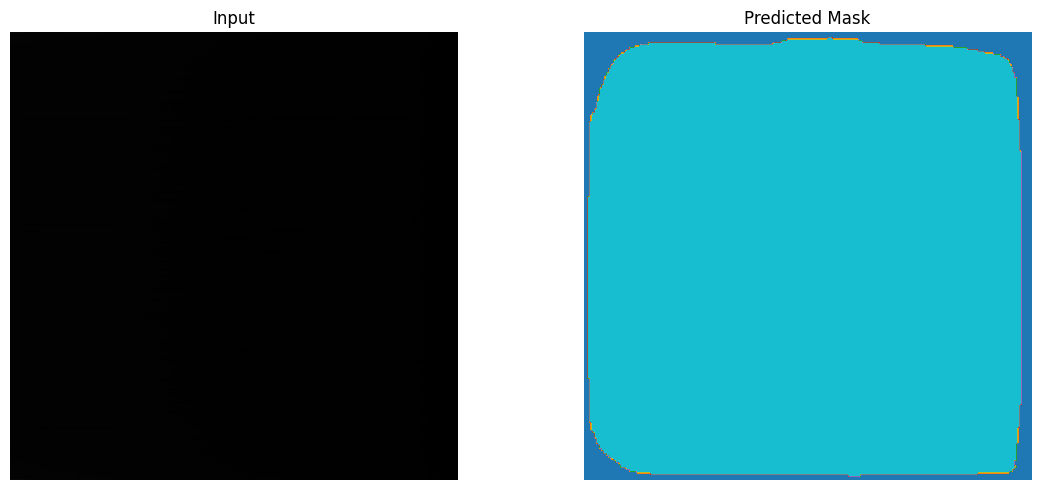

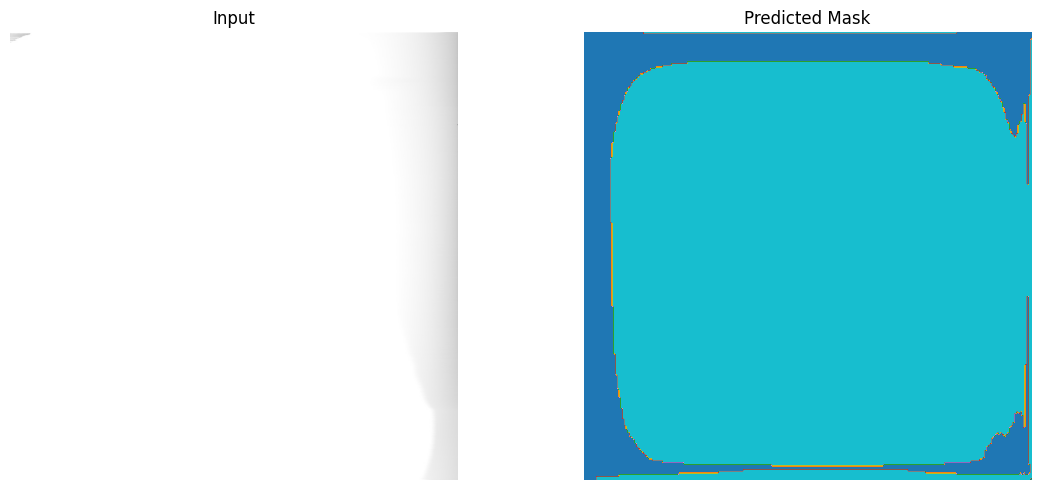

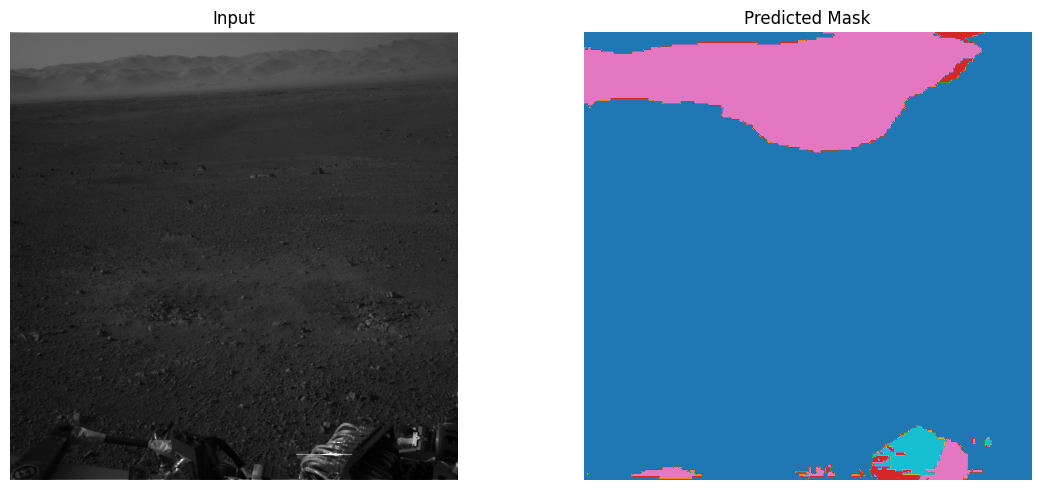

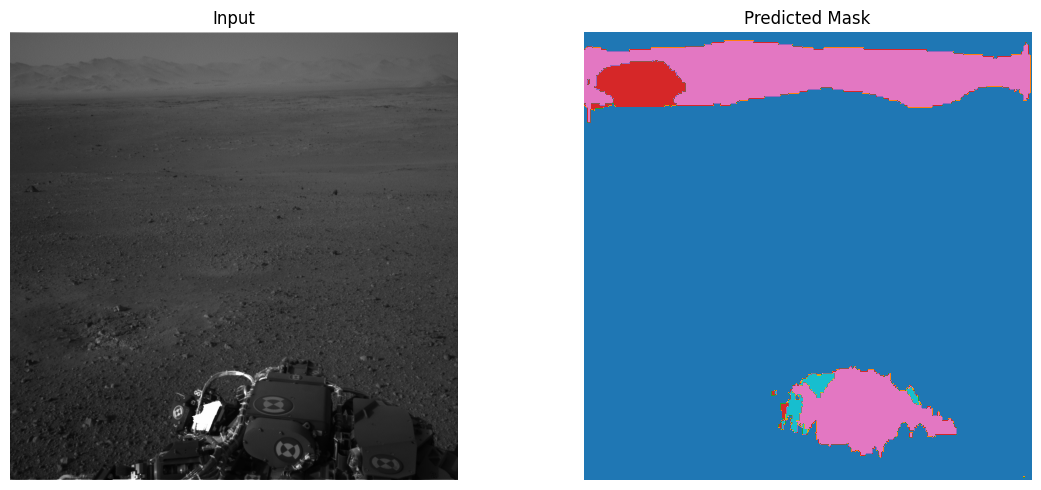

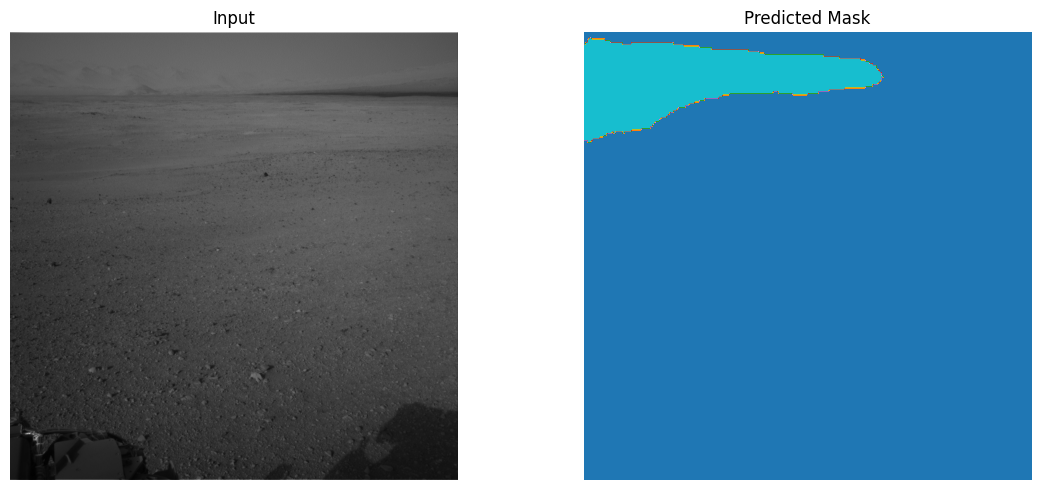

In [24]:
# 2.1) Notebook setup
%matplotlib inline
import os, glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# 2.2) Paths & device
SCRIPTED_MODEL = '/kaggle/working/segmentation_model.pt'   # from your training save
IMG_DIR        = '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr'
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2.3) Gather a handful of test images (any of these extensions)
patterns = ['*.jpg','*.JPG','*.jpeg','*.png','*.PNG']
val_img_paths = []
for p in patterns:
    val_img_paths += glob.glob(os.path.join(IMG_DIR, p))
val_img_paths = sorted(val_img_paths)[:5]
print("Running inference on:", val_img_paths)

# 2.4) Load your scripted model
model = torch.jit.load(SCRIPTED_MODEL, map_location=DEVICE)
model.to(DEVICE).eval()

# 2.5) Pre‐processing (must match your train pipeline)
preprocess = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225]),
])

# 2.6) Inference & plotting
def infer_and_plot(img_path):
    img = Image.open(img_path).convert('RGB')
    inp = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(inp)                           # N×C×H×W
        pred_mask = torch.argmax(logits, dim=1)[0]    # H×W
        pred_mask = pred_mask.cpu().numpy()

    fig, axes = plt.subplots(1,2, figsize=(12,5))
    axes[0].imshow(img);         axes[0].axis('off'); axes[0].set_title("Input")
    axes[1].imshow(pred_mask, cmap='tab10')
    axes[1].axis('off');        axes[1].set_title("Predicted Mask")
    plt.tight_layout()
    plt.show()

# 2.7) Run it
if not val_img_paths:
    print("❗ Still no images found! Check that IMG_DIR is correct.")
else:
    for p in val_img_paths:
        infer_and_plot(p)


Randomly selected: ['/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLB_577451690EDR_F0692456NCAM00289M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLB_546643139EDR_F0622452NCAM07753M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLB_460162232EDR_F0400000NCAM00320M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NRB_585608579EDR_F0720202NCAM00255M1.JPG', '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr/NLA_402109354EDR_F0043076NCAM00437M1.JPG']


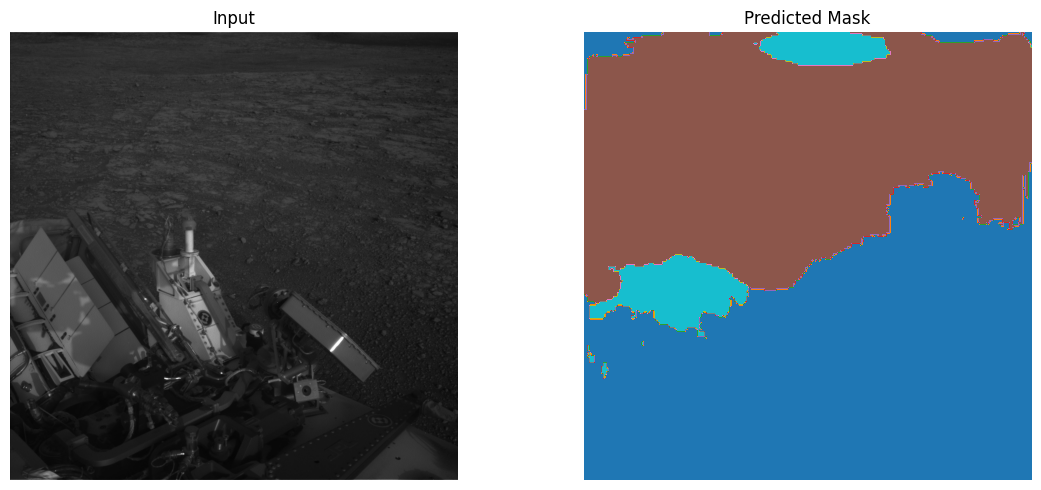

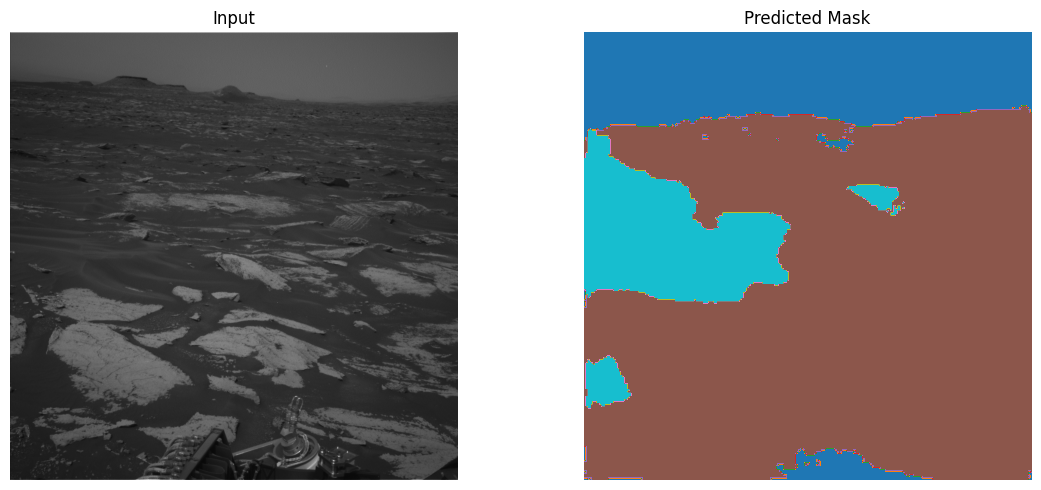

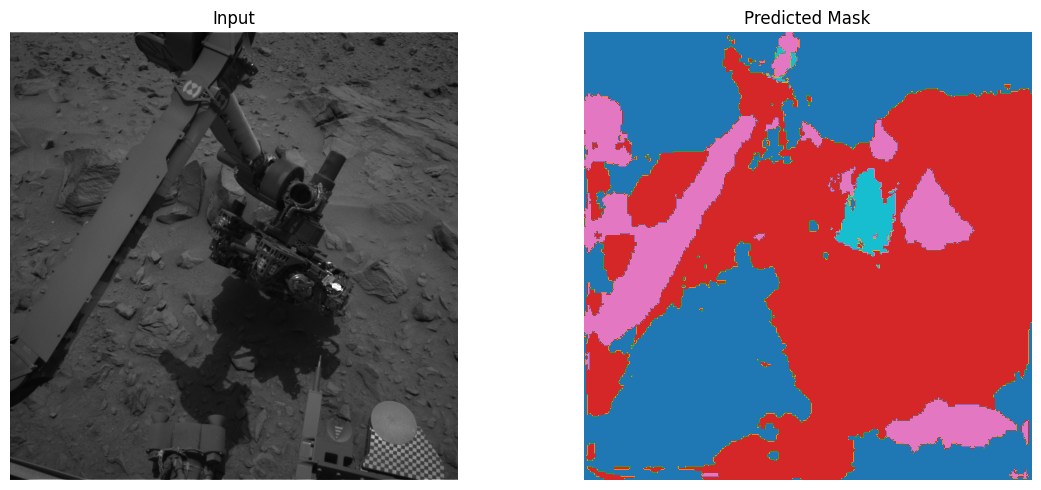

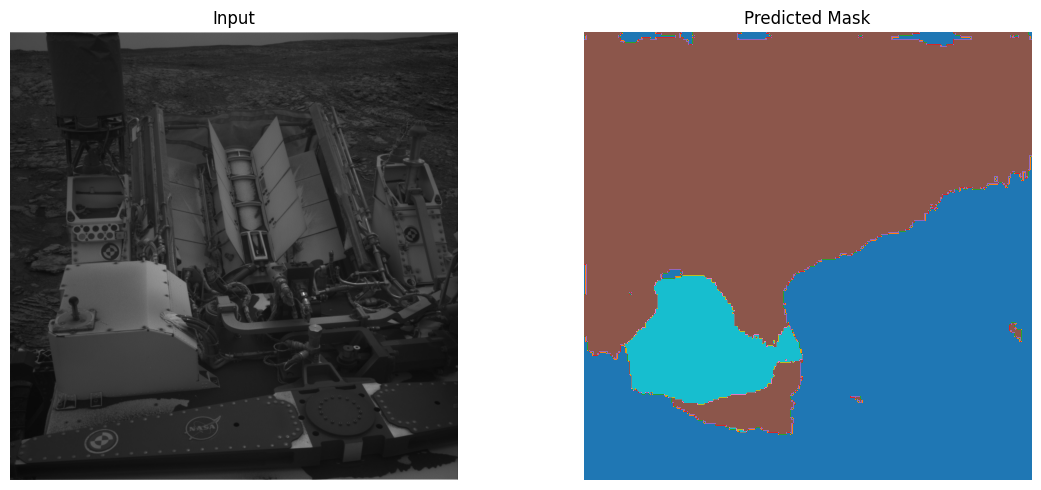

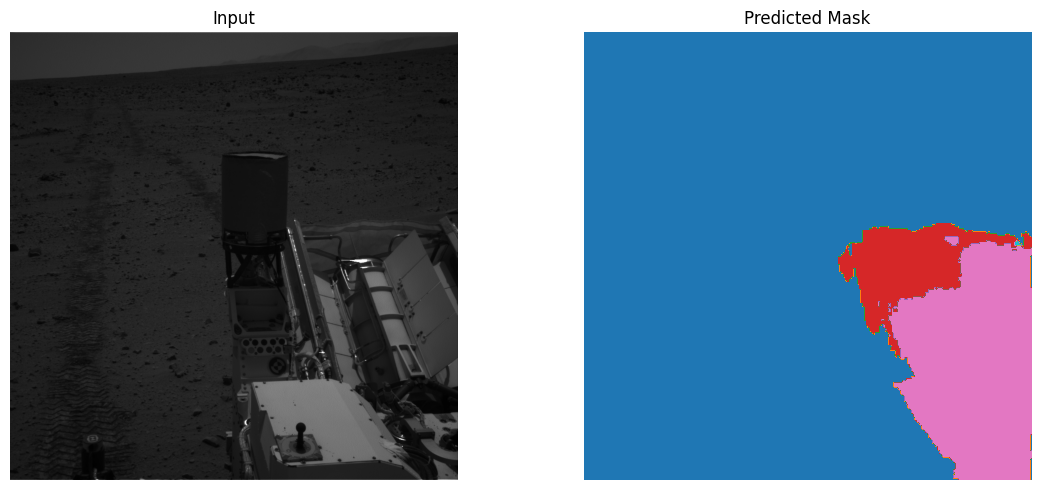

In [26]:
# Inference: random-sample version
%matplotlib inline
import os, glob, random
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# Paths & device (adjust if needed)
SCRIPTED_MODEL = '/kaggle/working/segmentation_model.pt'
IMG_DIR        = '/kaggle/input/ai4mars-terrainaware-autonomous-driving-on-mars/ai4mars-dataset-merged-0.1/msl/images/edr'
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load scripted model
model = torch.jit.load(SCRIPTED_MODEL, map_location=DEVICE)
model.to(DEVICE).eval()

# Preprocessing (must match training)
preprocess = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std =[0.229,0.224,0.225]),
])

# Gather all image paths (jpg/jpeg/png; case-insensitive)
patterns = ['*.jpg','*.JPG','*.jpeg','*.JPEG','*.png','*.PNG']
all_paths = []
for p in patterns:
    all_paths += glob.glob(os.path.join(IMG_DIR, p))
all_paths = sorted(all_paths)

def infer_and_plot(img_path):
    img = Image.open(img_path).convert('RGB')
    inp = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(inp)                   # shape: 1×C×H×W
        mask   = torch.argmax(logits, dim=1)  # shape: 1×H×W
        mask   = mask[0].cpu().numpy()

    fig, axes = plt.subplots(1,2, figsize=(12,5))
    axes[0].imshow(img); axes[0].set_title("Input");         axes[0].axis('off')
    axes[1].imshow(mask, cmap='tab10'); axes[1].set_title("Predicted Mask"); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# Each run: pick 5 random images and plot
if len(all_paths) == 0:
    print("No images found in", IMG_DIR)
else:
    sample_paths = random.sample(all_paths, k=min(5, len(all_paths)))
    print("Randomly selected:", sample_paths)
    for p in sample_paths:
        infer_and_plot(p)
